**Section 1:**
Initialization & ConfigurationIn this section, we define our file paths and hyper-parameters. We use an image size of $246 \times 246$ to match the requirements of the pre-trained MobileNetV2 architecture.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
import time
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2

print("--- Section 1: Initializing Environment ---")
TRAIN_CSV = "/kaggle/input/competitions/diabetic-retinopathy-detection/trainLabels.csv.zip"
IMAGE_DIR = "/kaggle/input/datasets/josephrynkiewicz/diabetic-retinopathy-train-unzipped/train/"
IMG_SIZE = (246, 246)
BATCH_SIZE = 32
MAX_EPOCHS = 50

--- Section 1: Initializing Environment ---


**Section 2:** Data Loading & Balancing
The original dataset is heavily imbalanced, with roughly 73.5% of images labeled as "No DR". To prevent the model from simply guessing "Healthy" every time, we create a balanced 50/50 dataset.

In [3]:
print("\n--- Section 2: Loading and Balancing Data ---")
start_time = time.time()

df = pd.read_csv(TRAIN_CSV)
df['filepath'] = df['image'].apply(lambda x: os.path.join(IMAGE_DIR, f"{x}.jpeg"))
df['label'] = df['level'].apply(lambda x: 1 if x > 0 else 0)

# Filter for files that exist in your specific Kaggle subset
df = df[df['filepath'].apply(os.path.exists)].reset_index(drop=True)

# Separate classes: Level 0 vs Levels 1-4
df_no_dr = df[df['label'] == 0]
df_dr = df[df['label'] == 1]

# Sample equally to create a balanced training set
sample_size = min(len(df_no_dr), len(df_dr), 1200) 
balanced_df = pd.concat([
    df_no_dr.sample(sample_size, random_state=42),
    df_dr.sample(sample_size, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Final dataset size: {len(balanced_df)} ({sample_size} images per class).")


--- Section 2: Loading and Balancing Data ---
Final dataset size: 2400 (1200 images per class).


**Section 3:** Image Preprocessing
We convert images to RGB and normalize pixel values. Normalization is critical so that the neural network's weights can converge efficiently.

In [4]:

print("\n--- Section 3: Preprocessing Images ---")
def load_and_preprocess(filepath):
    img = cv2.imread(filepath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    return img / 255.0 

X = np.array([load_and_preprocess(f) for f in balanced_df['filepath']])
y = balanced_df['label'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Preprocessing took {time.time() - start_time:.2f} seconds.")



--- Section 3: Preprocessing Images ---
Preprocessing took 382.55 seconds.


**Section 4:** Model Architecture (Transfer Learning)
Instead of a simple MLP, we use MobileNetV2. This model was pre-trained on millions of images and is excellent at feature extraction for medical imaging.

In [5]:

print("\n--- Section 4: Building Transfer Learning Model ---")

def build_transfer_model():
    base_model = MobileNetV2(input_shape=(246, 246, 3), include_top=False, weights='imagenet')
    base_model.trainable = False # Freeze the base to keep pre-trained features
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid') # 0 = Healthy, 1 = DR Detected
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_transfer_model()



--- Section 4: Building Transfer Learning Model ---


/tmp/ipykernel_55/3848414301.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(246, 246, 3), include_top=False, weights='imagenet')
2026-03-25 11:14:20.804309: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Section 5:** Training with Early Stopping
We implement an EarlyStopping callback to stop training once the val_loss stops improving. This ensures we save the version of the model that generalizes best to new data.

In [6]:


print("\n--- Section 5: Starting Model Training ---")

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)

model.save("dr_detection_final.keras")



--- Section 5: Starting Model Training ---
Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.5126 - loss: 0.7938 - val_accuracy: 0.5833 - val_loss: 0.6681
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.5626 - loss: 0.6852 - val_accuracy: 0.5917 - val_loss: 0.6697
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5970 - loss: 0.6637 - val_accuracy: 0.5875 - val_loss: 0.6573
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5998 - loss: 0.6654 - val_accuracy: 0.6000 - val_loss: 0.6587
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6092 - loss: 0.6470 - val_accuracy: 0.5854 - val_loss: 0.6695
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.6336 - loss: 0.6382 - val_accuracy: 0.5750 - val_loss: 0.6685
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.6380 - loss: 0.6342 - val_accuracy: 0.6021 - val_loss: 0.6587
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.6295 - lo

**Section 6:** Visualizing Results
A good model should show decreasing loss and increasing accuracy for both training and validation sets.


--- Section 6: Visualizing Training Results ---


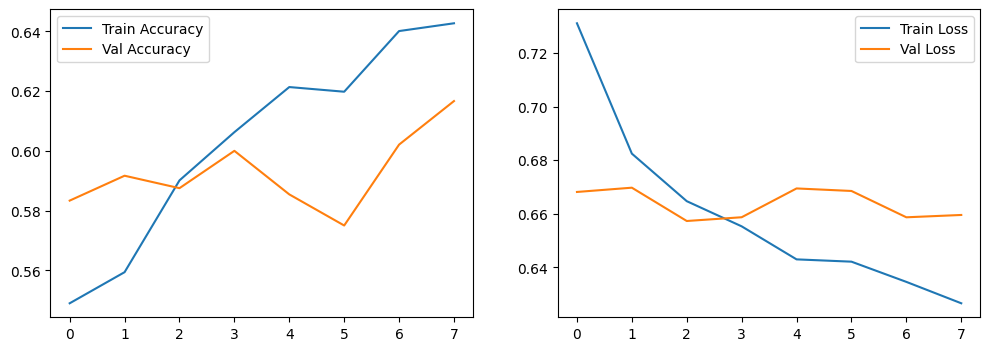

In [7]:
print("\n--- Section 6: Visualizing Training Results ---")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()


**Section 7:** Inference Test
Finally, we run a test on a specific image. A score $\ge 0.5$ indicates the presence of Diabetic Retinopathy.

In [8]:
print("\n--- Section 7: Final Inference Test ---")

def predict_eye(img_path):
    if not os.path.exists(img_path):
        return "File Not Found"
    
    img = load_and_preprocess(img_path)
    img_batch = np.expand_dims(img, axis=0)
    pred = model(img_batch, training=False).numpy()[0][0]
    
    return f"Score: {pred:.4f} | Status: {'DR Detected' if pred >= 0.5 else 'Healthy'}"

# Test on image 10150_left (a known Level 4 case)
print(predict_eye(os.path.join(IMAGE_DIR, "10150_left.jpeg")))


--- Section 7: Final Inference Test ---
Score: 0.4403 | Status: Healthy


**Section 8:** Clean Inference Testing (Missing Files Removed)
In the standard dataset, Level 4 (Proliferative DR) cases are rare, making up less than 2% of the total images. Because of this, many unzipped subsets on Kaggle exclude them to save space. This code automatically identifies and removes those missing files from your test list.

In [9]:
import cv2
import numpy as np
import tensorflow as tf
import os

# Paths
model_path = "/kaggle/working/dr_detection_final.keras"
image_dir = "/kaggle/input/datasets/josephrynkiewicz/diabetic-retinopathy-train-unzipped/train/"

# Load model
model = tf.keras.models.load_model(model_path, compile=False)

def load_and_preprocess(filepath, target_size=(246, 246)):
    img = cv2.imread(filepath)
    if img is None: 
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img / 255.0
    return img

# IDs you want to check
potential_ids = [
    "10000_left", "10000_right", "10011_left", "10011_right", "10012_left", 
    "10012_right", "10017_left", "10017_right", "10021_left", "10021_right", 
    "10024_left", "10024_right", "10029_left", "10029_right", "10035_left", 
    "10035_right", "10037_left", "10040_left", "10040_right", "10041_left",
    "10084_left", "10084_right", "10138_left", "10138_right", "10150_left", 
    "10430_left", "10430_right", "10663_left", "10663_right", "11032_left", 
    "11032_right", "11105_left", "11105_right", "11130_left", "11130_right", 
    "11156_left", "11156_right", "11157_left", "11157_right", "11216_left"
]

# --- THE FIX: Filter only files that exist ---
file_names = [name for name in potential_ids if os.path.exists(os.path.join(image_dir, f"{name}.jpeg"))]

print(f"Found {len(file_names)} out of {len(potential_ids)} images.\n")
print(f"{'Image Name':<15} | {'Raw Pred':<10} | {'Prediction'}")
print("-" * 45)

for name in file_names:
    image_path = os.path.join(image_dir, f"{name}.jpeg")
    img = load_and_preprocess(image_path)
    
    if img is not None:
        img_batch = np.expand_dims(img, axis=0)
        pred_tensor = model(img_batch, training=False)
        pred = pred_tensor.numpy()[0][0]
        
        label = "DR Detected" if pred >= 0.5 else "Healthy"
        print(f"{name:<15} | {pred:<10.4f} | {label}")

Found 16 out of 40 images.

Image Name      | Raw Pred   | Prediction
---------------------------------------------
10017_left      | 0.7922     | DR Detected
10017_right     | 0.6025     | DR Detected
10029_left      | 0.4323     | Healthy
10029_right     | 0.3596     | Healthy
10035_left      | 0.5627     | DR Detected
10035_right     | 0.5334     | DR Detected
10150_left      | 0.4403     | Healthy
11032_left      | 0.6452     | DR Detected
11032_right     | 0.6008     | DR Detected
11130_left      | 0.4981     | Healthy
11130_right     | 0.5135     | DR Detected
11156_left      | 0.4164     | Healthy
11156_right     | 0.4360     | Healthy
11157_left      | 0.3497     | Healthy
11157_right     | 0.3826     | Healthy
11216_left      | 0.5076     | DR Detected


**Section 9:** Visual Interactive Diagnosis
Run this block in a new cell. It will show you a gallery of the 16 found images and then let you pick one to see the model's heatmap-style diagnosis.



--- Initializing Image Gallery ---


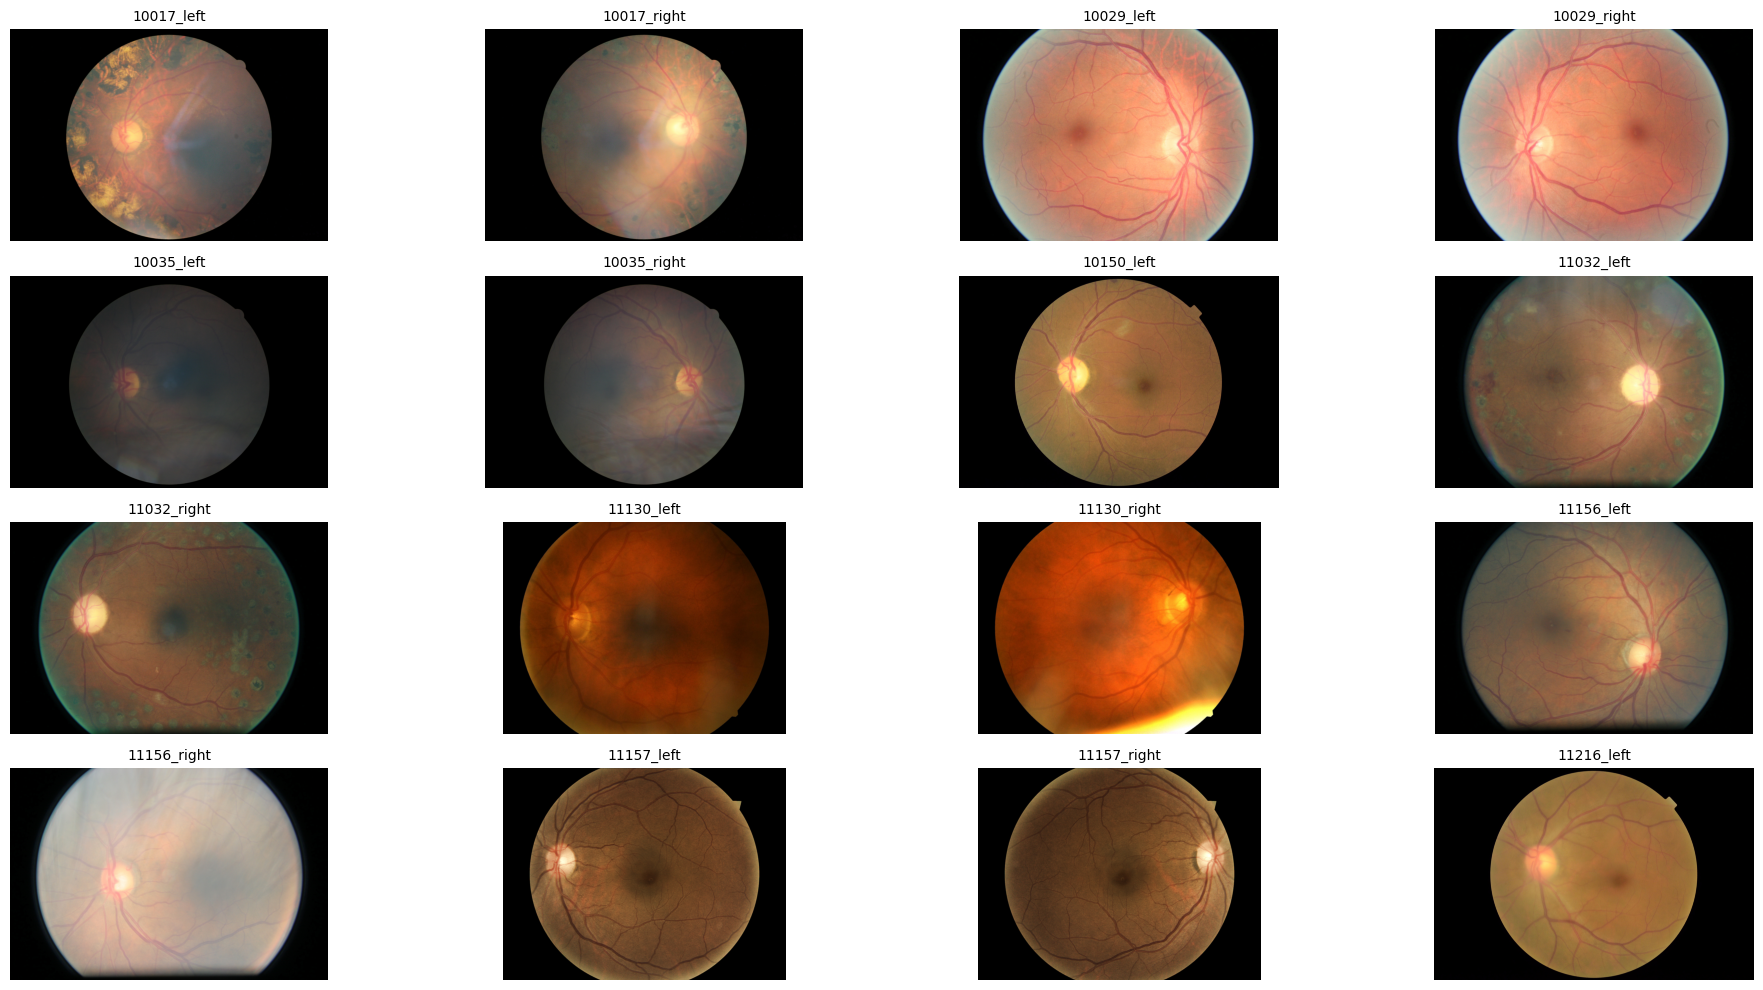


--- Interactive Selection ---


In [10]:
import cv2
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Setup ---
model_path = "/kaggle/working/dr_detection_final.keras"
image_dir = "/kaggle/input/datasets/josephrynkiewicz/diabetic-retinopathy-train-unzipped/train/"
model = tf.keras.models.load_model(model_path, compile=False)

file_names = [
    "10017_left", "10017_right", "10029_left", "10029_right",
    "10035_left", "10035_right", "10150_left", "11032_left",
    "11032_right", "11130_left", "11130_right", "11156_left",
    "11156_right", "11157_left", "11157_right", "11216_left"
]

def load_for_display(name):
    path = os.path.join(image_dir, f"{name}.jpeg")
    img = cv2.imread(path)
    if img is None: return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==========================================
# PART A: SHOW ALL IMAGES IN A GALLERY
# ==========================================
print("--- Initializing Image Gallery ---")
plt.figure(figsize=(20, 10))
for i, name in enumerate(file_names):
    img = load_for_display(name)
    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.title(name, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

# ==========================================
# PART B: INTERACTIVE DIAGNOSIS TOOL
# ==========================================
def load_and_preprocess(filepath):
    img = cv2.imread(filepath)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (246, 246))
    return img_resized / 255.0, img_rgb

output = widgets.Output()
dropdown = widgets.Dropdown(options=file_names, description='Select ID:')
button = widgets.Button(description='Run Diagnosis', button_style='success')

def on_button_clicked(b):
    with output:
        clear_output()
        selected_name = dropdown.value
        path = os.path.join(image_dir, f"{selected_name}.jpeg")
        
        processed_img, raw_img = load_and_preprocess(path)
        img_batch = np.expand_dims(processed_img, axis=0)
        
        # Inference
        pred = model(img_batch, training=False).numpy()[0][0]
        
        label = "DR DETECTED" if pred >= 0.5 else "HEALTHY"
        color = 'red' if pred >= 0.5 else 'green'
        
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(raw_img)
        ax.set_title(f"ID: {selected_name}\nDiagnosis: {label}\nConfidence Score: {pred:.4f}", 
                     color=color, fontsize=14, fontweight='bold')
        ax.axis('off')
        plt.show()

button.on_click(on_button_clicked)

print("\n--- Interactive Selection ---")
display(widgets.VBox([dropdown, button, output]))